[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_9_Exercises.ipynb)

# 07.9: Exercises

These exercises use the same Titanic dataset from the rest of module 07. Each exercise asks a question and asks you to choose the right chart and write the code. There is usually more than one acceptable answer.

Run the setup cell first, then work through the exercises in order.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


---
## Part 1: Warm-up

These exercises recall a single seaborn call from the notebook. Focus on getting the call right and adding a title.

### Exercise 1

Plot the distribution of `fare`. Choose an appropriate bin width and apply a log scale on the x-axis so the shape is visible. Add a title and axis label.

In [2]:
# your code here

Text(0, 0.5, 'Number of passengers')

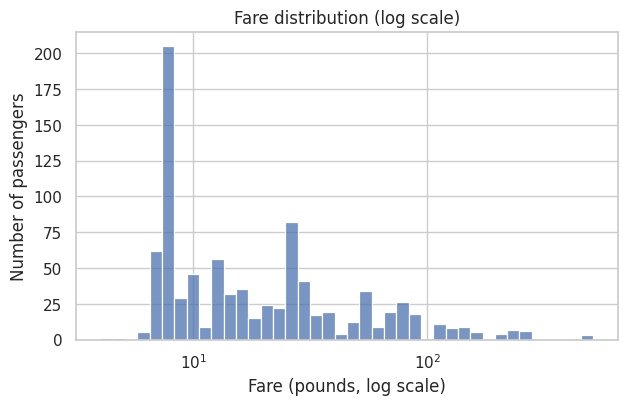

In [3]:
#@title Solution
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="fare", bins=40, log_scale=True, ax=ax)
ax.set_title("Fare distribution (log scale)")
ax.set_xlabel("Fare (pounds, log scale)")
ax.set_ylabel("Number of passengers")

### Exercise 2

Make a count plot of `pclass`. The bars should appear in order from class 1 to class 3. Add a title.

In [4]:
# your code here

Text(0, 0.5, 'Count')

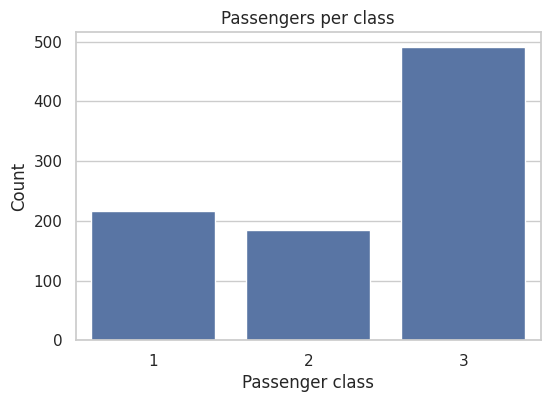

In [5]:
#@title Solution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="pclass", order=[1, 2, 3], ax=ax)
ax.set_title("Passengers per class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Count")

### Exercise 3

Show the mean survival rate by `sex` as a bar chart. Label the y-axis so it is clear the bars show a rate, not a count.

In [6]:
# your code here

(0.0, 1.0)

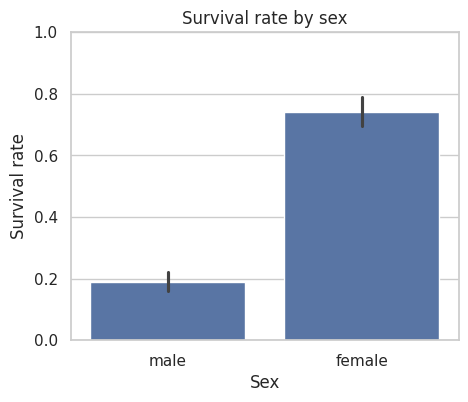

In [7]:
#@title Solution
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="sex", y="survived", errorbar="ci", ax=ax)
ax.set_title("Survival rate by sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

---
## Part 2: Comparisons

These exercises ask you to add a second variable using `hue=` or a second axis.

### Exercise 4

On one set of axes, compare the age distribution of survivors vs non-survivors. In the markdown cell below your code, write one sentence explaining why you chose `histplot` or `kdeplot` (either is acceptable, but explain your reasoning).

In [8]:
# your code here

*your explanation here*

Text(0, 0.5, 'Density')

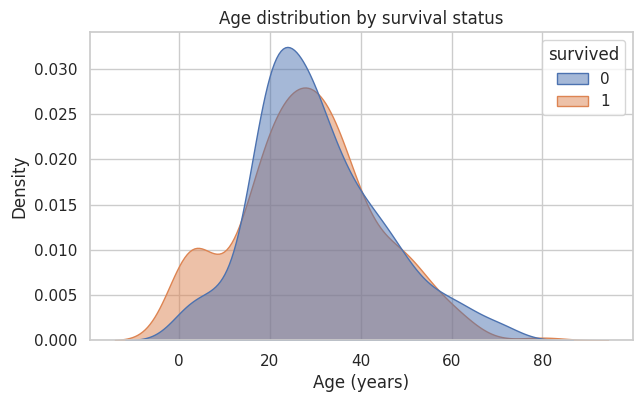

In [9]:
#@title Solution
# kdeplot with common_norm=False is a clean comparison because the overlapping
# curves are easier to follow than overlapping bars, and normalizing each group
# separately lets you compare shapes regardless of group size.
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(
    data=df, x="age",
    hue="survived",
    fill=True,
    common_norm=False,
    alpha=0.5,
    ax=ax
)
ax.set_title("Age distribution by survival status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")

### Exercise 5

Make a box plot of `fare` by `pclass`, split by `sex`. Hide the outliers and use a log scale on the y-axis. Order the classes 1, 2, 3.

In [10]:
# your code here

Text(0, 0.5, 'Fare (pounds, log scale)')

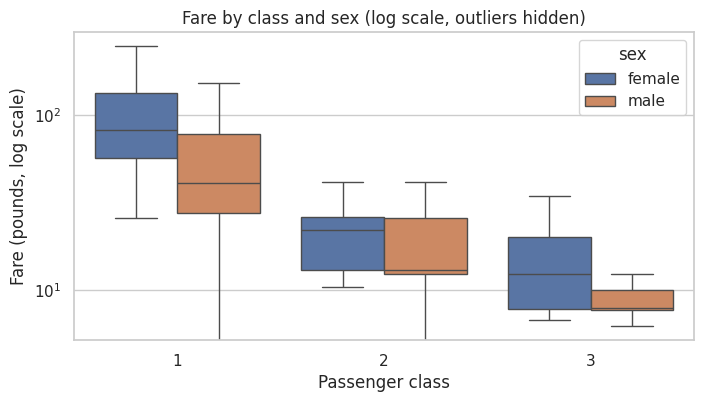

In [11]:
#@title Solution
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=df, x="pclass", y="fare",
    hue="sex",
    order=[1, 2, 3],
    showfliers=False,
    ax=ax
)
ax.set_yscale("log")
ax.set_title("Fare by class and sex (log scale, outliers hidden)")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Fare (pounds, log scale)")

### Exercise 6

Make a bar plot of survival rate by `pclass` with `sex` as `hue`. Order the classes 1, 2, 3. Label both axes and set the y-axis from 0 to 1.

In [12]:
# your code here

(0.0, 1.0)

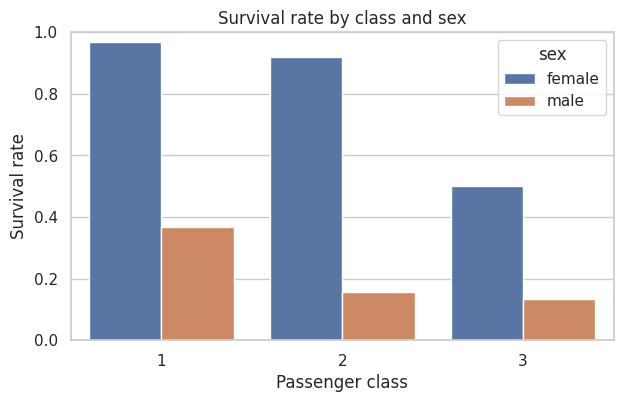

In [13]:
#@title Solution
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex",
    order=[1, 2, 3],
    errorbar=None,
    ax=ax
)
ax.set_title("Survival rate by class and sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

---
## Part 3: Relationships between two numeric variables

### Exercise 7

Make a scatter plot of `age` vs `fare`, colored by `survived`. Use `alpha=` to reduce overplotting. Does any clear pattern separate survivors from non-survivors in two dimensions?

In [14]:
# your code here

Text(0, 0.5, 'Fare (pounds)')

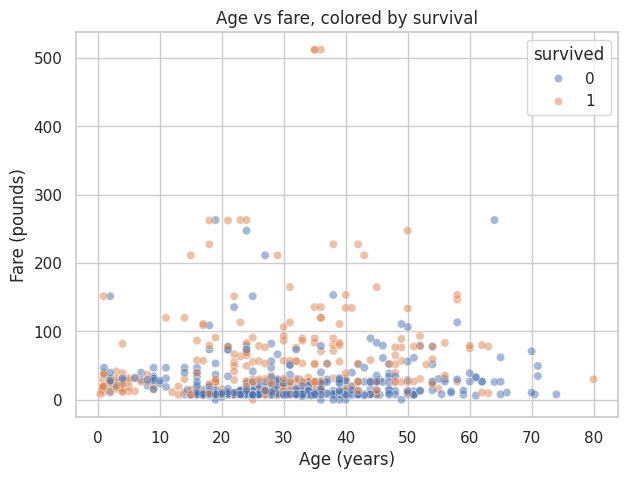

In [15]:
#@title Solution
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    hue="survived",
    alpha=0.5,
    ax=ax
)
ax.set_title("Age vs fare, colored by survival")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare (pounds)")
# Pattern: survivors (orange) concentrate at higher fares, but the two groups
# overlap substantially. No single diagonal line separates them; the outcome
# depended on multiple variables, not just age and fare.

### Exercise 8

Make a line plot showing survival rate as a function of age (rounded to the nearest 5 years), with a separate line for each `sex`. Set `errorbar=None` to keep the chart readable. In the markdown cell below, write one or two sentences about what you notice.

In [16]:
# your code here

*your observation here*

(0.0, 1.0)

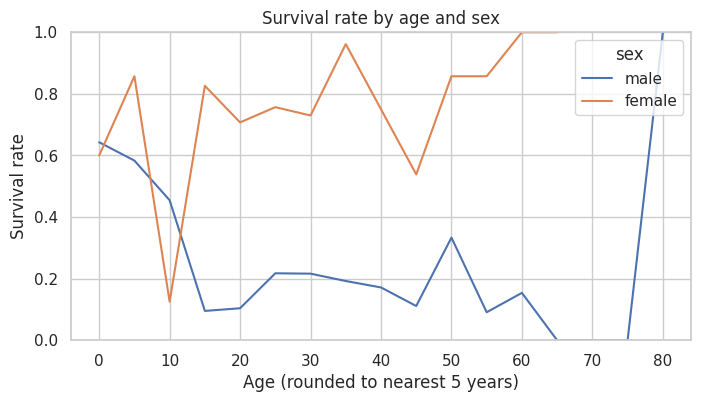

In [17]:
#@title Solution
df_line = df.dropna(subset=["age"]).copy()
df_line["age_r"] = (df_line["age"] / 5).round() * 5

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=df_line, x="age_r", y="survived",
    hue="sex",
    errorbar=None,
    ax=ax
)
ax.set_title("Survival rate by age and sex")
ax.set_xlabel("Age (rounded to nearest 5 years)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
# Female survival was high (above 60%) at almost every age.
# Male survival was low (under 25%) at most adult ages.
# Young boys had slightly better odds than adult men, reflecting evacuation priorities.

---
## Part 4: Faceting

### Exercise 9

Use `sns.relplot()` to make a scatter plot of `age` vs `fare`, faceted by `pclass` across columns and `sex` across rows. Color points by `survived`. Add axis labels and a figure title.

In [18]:
# your code here

Text(0.5, 1.02, 'Age vs fare by sex and class, colored by survival')

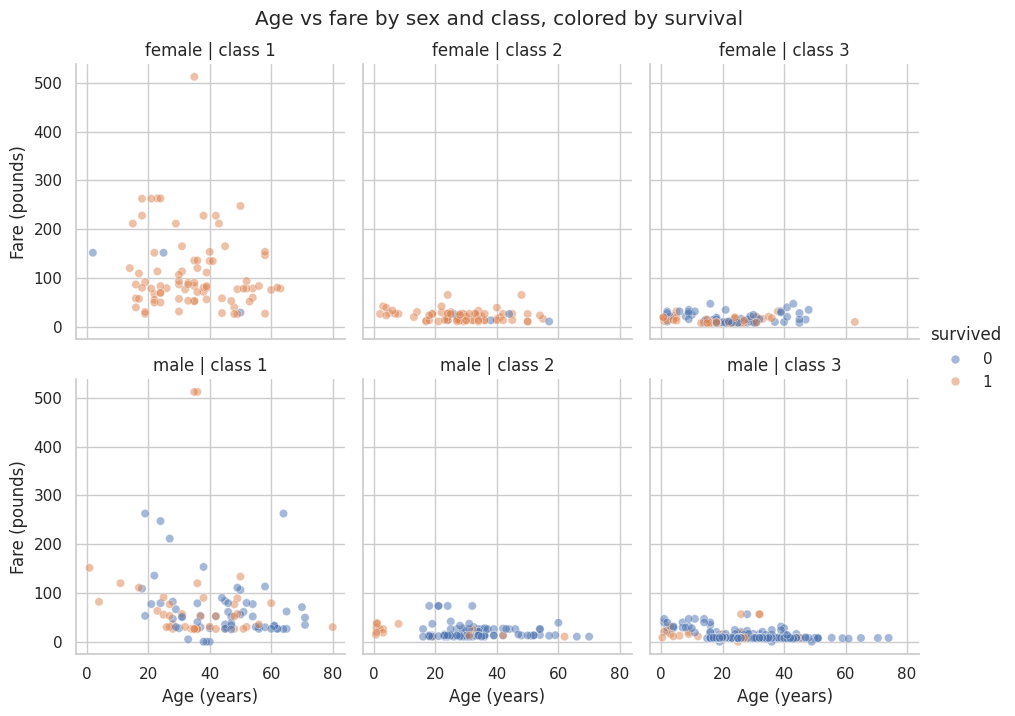

In [19]:
#@title Solution
g = sns.relplot(
    data=df.dropna(subset=["age"]),
    x="age", y="fare",
    hue="survived",
    col="pclass", row="sex",
    col_order=[1, 2, 3],
    row_order=["female", "male"],
    kind="scatter",
    alpha=0.5,
    height=3.5, aspect=0.9
)
g.set_axis_labels("Age (years)", "Fare (pounds)")
g.set_titles("{row_name} | class {col_name}")
g.figure.suptitle("Age vs fare by sex and class, colored by survival", y=1.02)

### Exercise 10

Use `sns.catplot()` to make box plots of `age` by `survived`, faceted by `pclass`. Order the classes 1, 2, 3. Add axis labels and a title.

In [20]:
# your code here

Text(0.5, 1.02, 'Age distribution by survival and class')

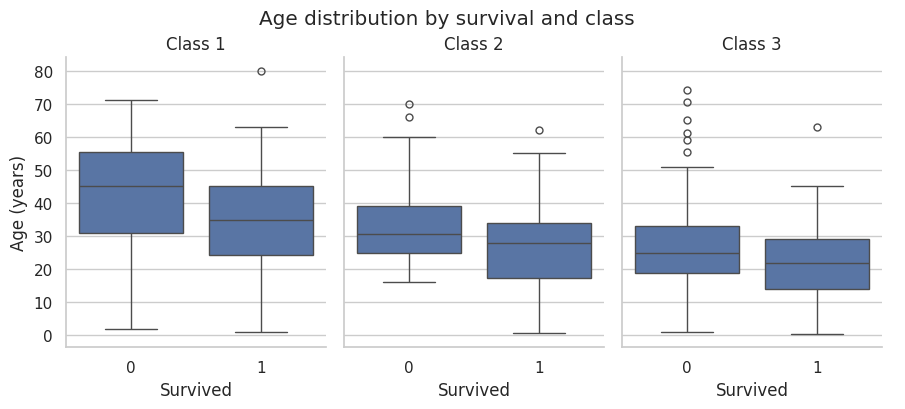

In [21]:
#@title Solution
g = sns.catplot(
    data=df,
    x="survived", y="age",
    col="pclass",
    col_order=[1, 2, 3],
    kind="box",
    height=4, aspect=0.75
)
g.set_axis_labels("Survived", "Age (years)")
g.set_titles("Class {col_name}")
g.figure.suptitle("Age distribution by survival and class", y=1.02)

---
## Part 5: Correlation and pair plots

### Exercise 11

Compute the correlation matrix of all numeric columns in `df` and display it as an annotated heatmap. Use a diverging colormap centered at 0 and fix the color scale at -1 to +1. Add a title.

In [22]:
# your code here

Text(0.5, 1.0, 'Correlation matrix: Titanic numeric variables')

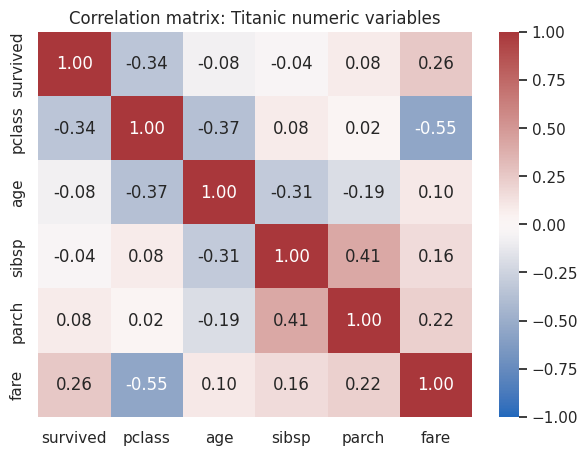

In [23]:
#@title Solution
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="vlag",
    vmin=-1, vmax=1, center=0,
    ax=ax
)
ax.set_title("Correlation matrix: Titanic numeric variables")

### Exercise 12

Make a pair plot of `age`, `fare`, `sibsp`, and `parch`, colored by `survived`, with KDEs on the diagonal. Use `corner=True` to show only the lower triangle. In the markdown cell below, write two to three sentences about a pattern you notice.

In [24]:
# your code here

*your observation here*

Text(0.5, 1.01, 'Pairwise relationships, colored by survival')

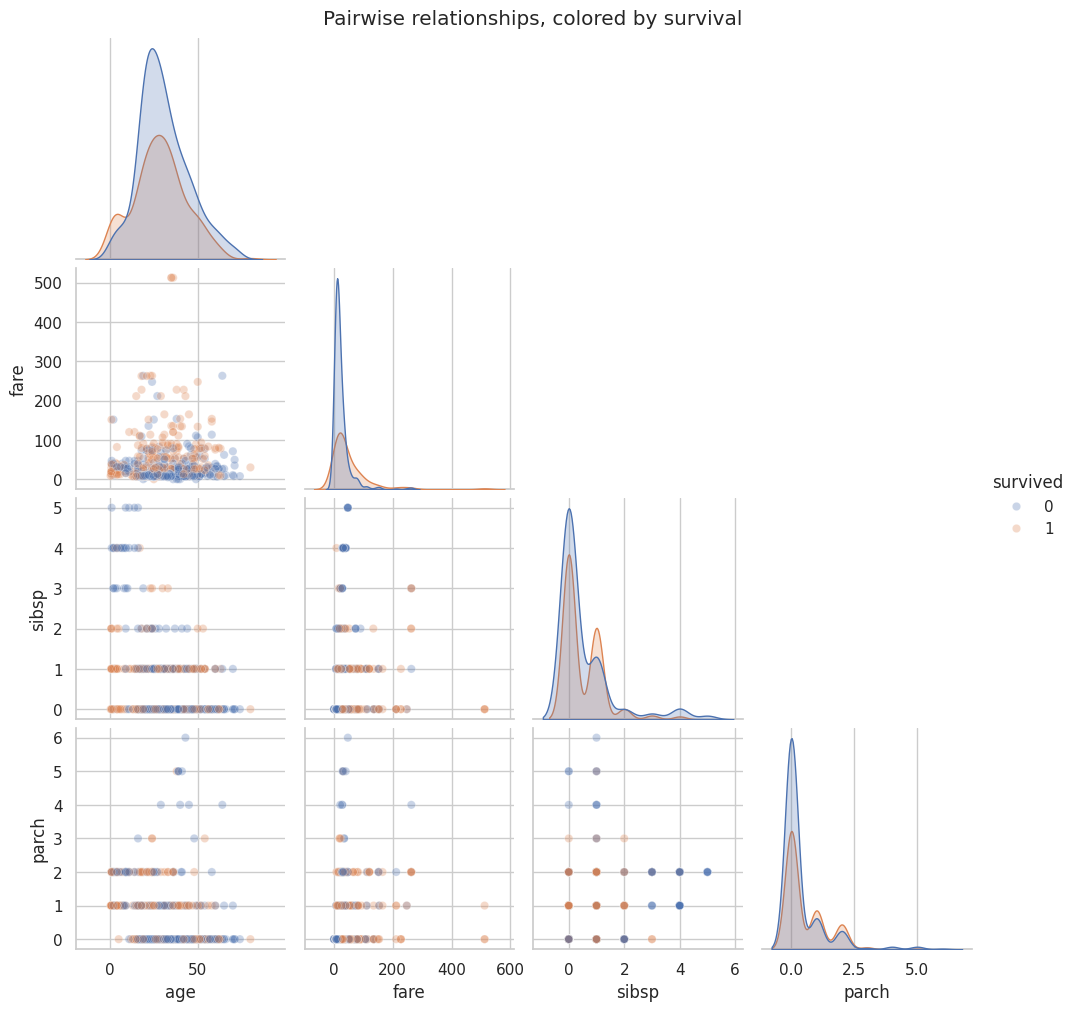

In [25]:
#@title Solution
g = sns.pairplot(
    df.dropna(subset=["age"]),
    vars=["age", "fare", "sibsp", "parch"],
    hue="survived",
    diag_kind="kde",
    plot_kws={"alpha": 0.3},
    corner=True
)
g.figure.suptitle("Pairwise relationships, colored by survival", y=1.01)
# The fare diagonal KDE shows survivors concentrated at higher fares.
# The age diagonal shows the small elevation of child survivors (bump near zero).
# No single pair of variables cleanly separates survivors from non-survivors;
# the scatter plots show substantial overlap in every panel.

---
## Part 6: Polish

### Exercise 13

Pick your favorite chart from exercises 1 through 12. Rebuild it with:
- a descriptive title
- labeled axes with units where applicable
- a deliberately chosen palette (qualitative, sequential, or diverging)
- a figure size that gives the chart room to breathe
- saved to `figures/best_chart.png` at `dpi=150`

In [26]:
import os
os.makedirs("figures", exist_ok=True)

# your code here

saved to figures/best_chart.png


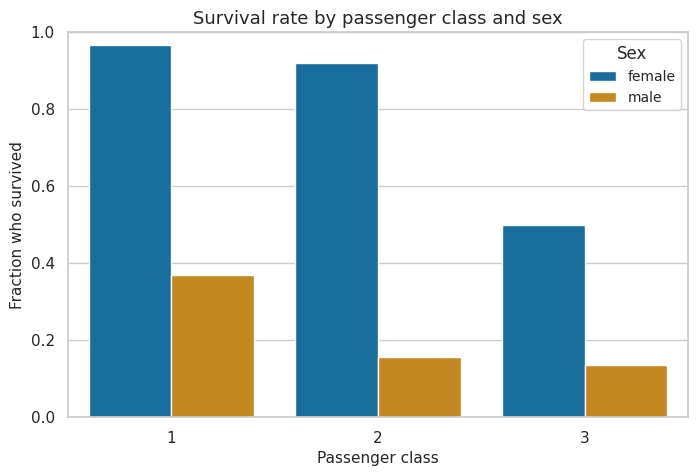

In [27]:
#@title Solution (rebuilding Exercise 6)
import os
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex",
    order=[1, 2, 3],
    palette="colorblind",
    errorbar=None,
    ax=ax
)
ax.set_title("Survival rate by passenger class and sex", fontsize=13)
ax.set_xlabel("Passenger class", fontsize=11)
ax.set_ylabel("Fraction who survived", fontsize=11)
ax.set_ylim(0, 1)
ax.legend(title="Sex", fontsize=10)

plt.savefig("figures/best_chart.png", dpi=150, bbox_inches="tight")
print("saved to figures/best_chart.png")

---
## Part 7: Challenge (optional)

### Exercise 14

Create a categorical `age_group` column using `pd.cut()` with four bins:
- Child: under 13
- Teen: 13 to 17
- Adult: 18 to 59
- Senior: 60 and above

Then make a grouped bar plot of survival rate by `age_group` and `sex`. Order the groups Child, Teen, Adult, Senior on the x-axis. Label both axes and add a title.

In [28]:
# your code here

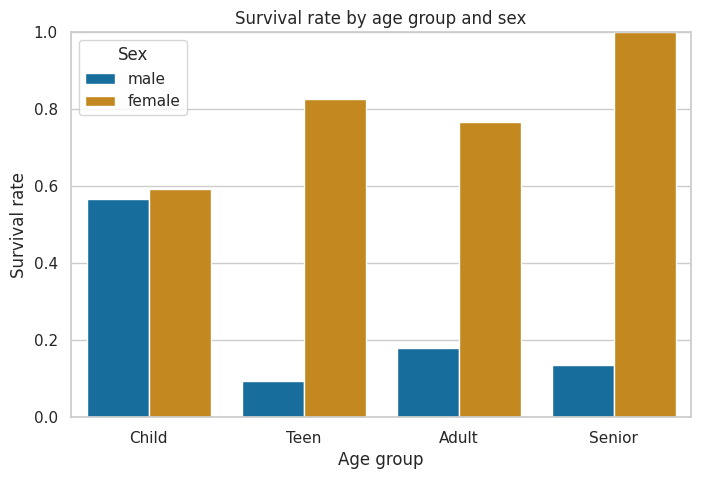

In [29]:
#@title Solution
df_age = df.dropna(subset=["age"]).copy()

df_age["age_group"] = pd.cut(
    df_age["age"],
    bins=[0, 13, 18, 60, 100],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)

group_order = ["Child", "Teen", "Adult", "Senior"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_age,
    x="age_group", y="survived",
    hue="sex",
    order=group_order,
    palette="colorblind",
    errorbar=None,
    ax=ax
)
ax.set_title("Survival rate by age group and sex")
ax.set_xlabel("Age group")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.legend(title="Sex")